# Create Training Files
Load in, concat, and filter parquets from face extraction step.

Considerations:
- Data Source
- Emotions
- Primary Face
- Confidence

In [1]:
import polars as pl
import plotly.express as px

In [2]:
def bar_plot_counts(df, col):
    counts_df = df[col].value_counts().sort("count", descending=True)
    fig = px.bar(counts_df, x=col, y="count", title="Value Counts Bar Plot")
    fig.show()

## DF Exploration
Use single df to dive into available data

In [3]:
pexels_v1 = '../data/processed/pexels_v1/summaries/face_level.parquet'

In [4]:
df = pl.read_parquet(pexels_v1)

In [5]:
df.head()

image_id,face_index,face_path,emotion,bbox_x,bbox_y,bbox_w,bbox_h,score,face_width,face_height,face_area
str,i64,str,str,i64,i64,i64,i64,f64,i64,i64,i64
"""angry__angry__pexels_14510569.…",0,"""../data/processed/pexels_v1/fa…","""angry""",2676,1091,1328,1328,0.616107,1328,1328,1763584
"""angry__angry__pexels_5659014.j…",0,"""../data/processed/pexels_v1/fa…","""angry""",2850,1520,1908,1908,0.791063,1908,1908,3640464
"""angry__angry__pexels_8059079.j…",0,"""../data/processed/pexels_v1/fa…","""angry""",2363,1341,1236,1236,0.844857,1236,1236,1527696
"""angry__angry__pexels_3958819.j…",0,"""../data/processed/pexels_v1/fa…","""angry""",1374,2492,1003,1003,0.951299,1003,1003,1006009
"""angry__angry__pexels_6669883.j…",0,"""../data/processed/pexels_v1/fa…","""angry""",2547,1124,909,909,0.935993,909,909,826281


In [6]:
df['face_index'].value_counts()

face_index,count
i64,u32
3,2
0,3099
1,257
2,15


In [7]:
df['emotion'].value_counts()

emotion,count
str,u32
"""sad""",556
"""neutral""",566
"""disgust""",25
"""happy""",724
"""surprise""",518
"""angry""",558
"""fear""",426


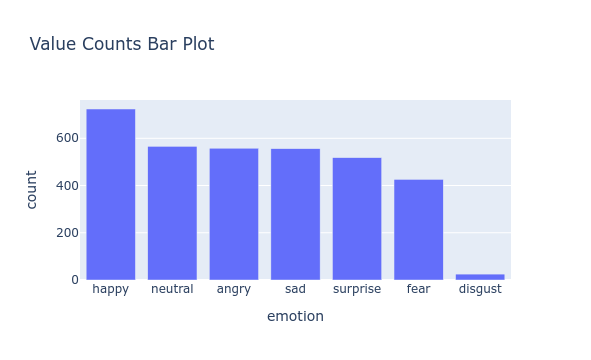

In [8]:
bar_plot_counts(df, "emotion")

## Concat DFs
Combine data sources to create a training file with selected faces.

In [9]:
pexels_v1 = '../data/processed/pexels_v1/summaries/face_level.parquet'
pexels_v2 = '../data/processed/pexels_v2/summaries/face_level.parquet'
pexels_v3 = '../data/processed/pexels_v3/summaries/face_level.parquet'

pixabay_v1 = '../data/processed/pixabay_v1/summaries/face_level.parquet'
pixabay_v2 = '../data/processed/pixabay_v2/summaries/face_level.parquet'
pixabay_v3 = '../data/processed/pixabay_v3/summaries/face_level.parquet'

In [10]:
all_pulls = [
    pexels_v1,
    pexels_v2,
    pixabay_v1,
    pixabay_v2
]

In [11]:
def combine_and_eda(file_list, drop_list =['disgust', 'neutral'], primary_only=True):
    combined_df = pl.read_parquet(file_list)
    print(f"Shape of all input: {combined_df.shape}")
    if drop_list:
        combined_df = combined_df.filter(~pl.col('emotion').is_in(drop_list))
        print(f"Shape after dropping: {combined_df.shape}")
    if primary_only:
        combined_df = combined_df.filter(pl.col('face_index')==0)
        print(f"Shape after primary only: {combined_df.shape}")
    bar_plot_counts(combined_df, "emotion")
    return combined_df

Shape of all input: (13967, 12)
Shape after dropping: (12105, 12)
Shape after primary only: (10949, 12)


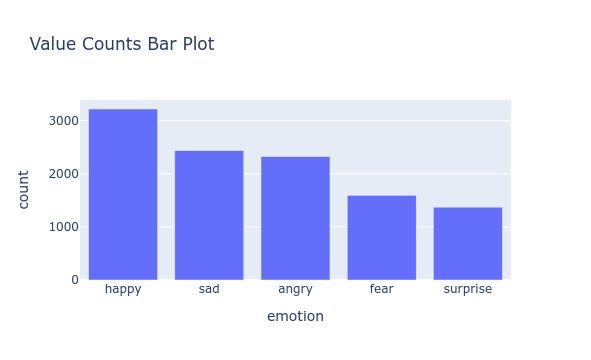

In [12]:
training_df = combine_and_eda(file_list=all_pulls)

In [13]:
training_df.write_parquet('../data/training_files/pex_pix_v3_primary.parquet')

In [14]:
training_df['face_path'].len()

10949

In [15]:
training_df['face_path'].n_unique()

10949

In [16]:
pexels_v3 = [
    pexels_v1,
    pexels_v2
]

Shape of all input: (9709, 12)
Shape after dropping: (8189, 12)
Shape after primary only: (7211, 12)


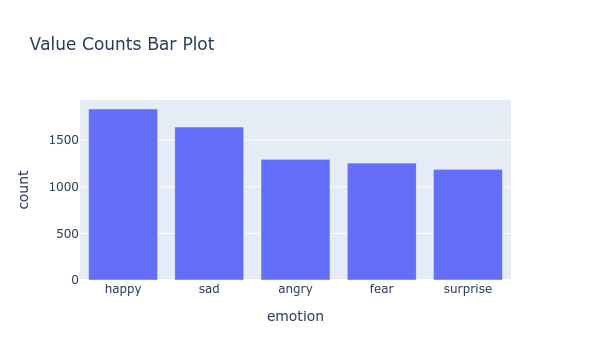

In [17]:
pexels_df = combine_and_eda(file_list=pexels_v3)

In [18]:
pexels_df.write_parquet('../data/training_files/pexels_v3_primary.parquet')

In [19]:
pixabay_v3 = [
    pixabay_v1,
    pixabay_v2
]

Shape of all input: (4258, 12)
Shape after dropping: (3916, 12)
Shape after primary only: (3738, 12)


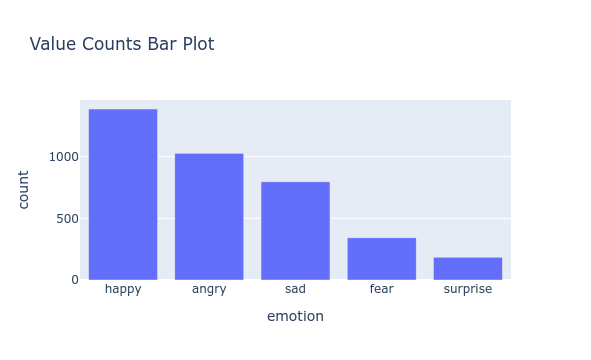

In [20]:
pixabay_df = combine_and_eda(file_list=pixabay_v3)

In [21]:
pixabay_df.write_parquet('../data/training_files/pixabay_v3_primary.parquet')